In [269]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('credit_risk_dataset.csv')


# Fase 1: Análise Exploratória de Dados (EDA)

#### Descritiva e Estatística:
Exiba explicitamente o tamanho total da base (linhas e colunas), 
os tipos de dados de cada variável e o sumário estatístico descritivo 
(médias, mínimos, máximos e quartis via .describe()) e etc

In [270]:

display(df) # DataFrame
print(f"Dimensões: Linhas: {df.shape[0]} - Colunas: {df.shape[1]}\n") # Dimensão
print(f"Tipos de Dados:\n{df.dtypes}") # Tipo de dados
df.describe() # Estatísticas



,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


Dimensões: Linhas: 32581 - Colunas: 12

Tipos de Dados:
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


#### Gráficos

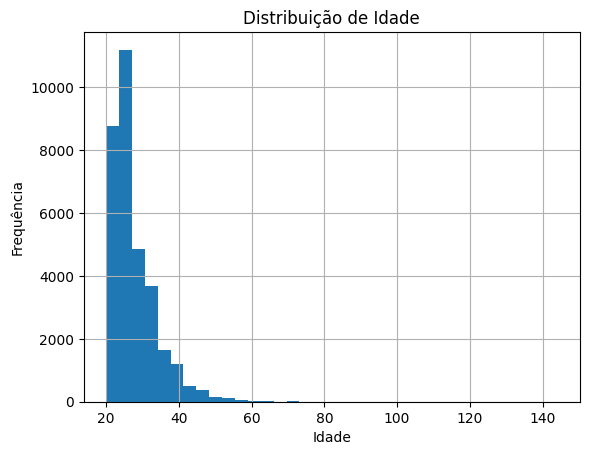

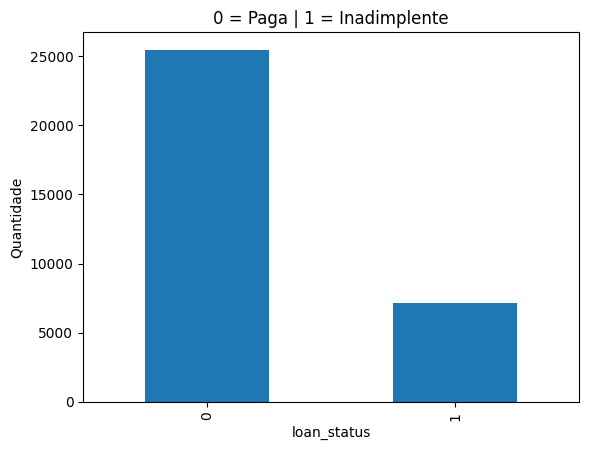

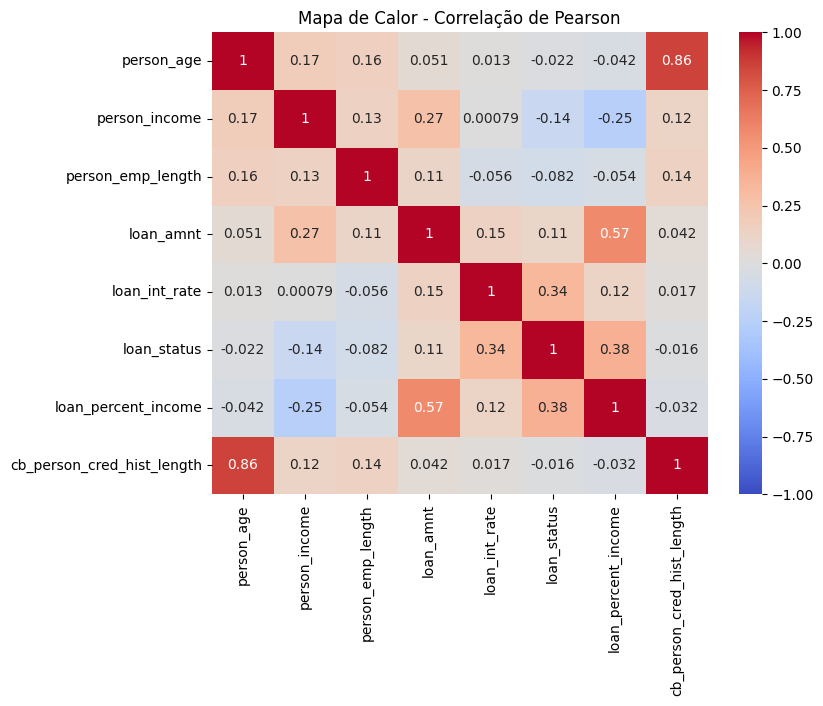

In [271]:
#Histograma
df['person_age'].hist(bins=35)
plt.title('Distribuição de Idade')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

#Gráfico de Barra #
df['loan_status'].value_counts().plot(kind='bar')
plt.title('0 = Paga | 1 = Inadimplente')
plt.xlabel('loan_status')
plt.ylabel('Quantidade')
plt.show()

#Gráfico Pearson
matriz_correlacao = df.corr(method='pearson', numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Mapa de Calor - Correlação de Pearson')
plt.show()

### Tomada de Decisão: Escreva um parágrafo analítico interpretando o que a estatística e os gráficos revelaram sobre os dados e como isso guiará sua estratégia de preparação.
- Através do comando describe foi possível verificar que existe Outliers na coluna Idade
- Foi possível comprovar o outlier idade
- Através da correlação de Pearson o Heatmap mostrou que a coluna alvo: loan_status tem certa relação com as colunas loan_int_rate e loan_percent_income
- teste

# Fase 2: Tratamento e Limpeza

### Limpeza de Duplicadas:

In [272]:
df_limpo = df.copy()

print(f"Quantidade de Linhas Duplicadas: {df_limpo.duplicated().sum()}") # Soma total das linhas duplicadas
#display(df_limpo[df_limpo.duplicated()])
print(f"Linhas antes da remoção: {df_limpo.shape[0]}")
df_limpo = df_limpo.drop_duplicates()
print(f"Linhas após remoção: {df_limpo.shape[0]}") 

Quantidade de Linhas Duplicadas: 165
Linhas antes da remoção: 32581
Linhas após remoção: 32416


### Verificação e Tratamento de Valores Nulos:

In [273]:
# Identificação de Colunas com dados ausentes
print(f"Coluna:                   Nulos:\n{df_limpo.isna().sum()}")
print('\nPorcentagem de dados Ausentes:')

#Calculando porcentagem de ausentes em relação ao total de registros
porcentagem = (df_limpo.isna().mean() * 100)
print((porcentagem[porcentagem > 0]))

Coluna:                   Nulos:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3095
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Porcentagem de dados Ausentes:
person_emp_length    2.736303
loan_int_rate        9.547754
dtype: float64


#### Tratamento da Coluna person_emp_length (Tempo de emprego)

In [274]:
# Imputar Mediana na coluna person_emp_length
mediana_person_emp_length = df_limpo['person_emp_length'].median()
df_limpo['person_emp_length'] = df_limpo['person_emp_length'].fillna(mediana_person_emp_length)
print("Nulos restantes:", df_limpo['person_emp_length'].isna().sum())

Nulos restantes: 0


#### Tratamento Coluna loan_int_rate (Taxa de Juros)
- Teste para verificar a melhor abordagem para tratar os valores ausentes
- Verificando se ha correlação entre a variável loan_grade(Classificação) e a variável alvo: "loan_status", caso tenha uma relação fraca/moderada/forte, será importante tratar os dados ausentes da melhor maneira para evitar distorções
- Verificado que Linhas com loan_int_rate(Taxa de Juros) ausentes possuem Classificações preenchidas
- Possibilidade de linhas com loan_int_rate(Taxa de Juros) preenchidos possuírem Medianas diferentes por loan_grade(classificações), pois classificações recebem taxas de juros diferentes
- Se a hipótese for comprovada seria interessante comparar a "Mediana geral" de todas as Classificações com a "Mediana individual" de cada Classificação e comprovar se a mediana geral pode causar distorções


In [275]:
#Mapeamento de coluna nominal para numeral
ordem_classificacao = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
teste_classificacao_num = df_limpo['loan_grade'].map(ordem_classificacao)
#Verificar Correlação com a Coluna alvo: 
correlacao_classificacao = teste_classificacao_num.corr(df_limpo['loan_status'])
print("\nCORRELAÇÃO: loan_grade x loan_status:", correlacao_classificacao)
#Ver porcentagem de cada classificação
porcentagem = (df_limpo['loan_grade'].value_counts(normalize=True) * 100).round(2)
print(f"Porcentagem das Classificações em Relação ao Todo:\n{porcentagem.astype(str) + '%'}")

#Verificar As medianas para tomada de decisão 
print("\n-----Medianas------")
#Verificar Mediana Geral e Comparar com a Mediana por Classificação
print("MEDIANA GERAL:", df_limpo['loan_int_rate'].median())
print("MEDIANA POR CLASSIFICAÇÃO:\n", df_limpo.groupby('loan_grade')['loan_int_rate'].median())

#Imputação
medianas_classificacao = df_limpo.groupby('loan_grade')['loan_int_rate'].median() #Agrupa a Mediana por Classificação (A,B,C,D,E,F,G)

medianas_classificacao_num = df_limpo['loan_grade'].map(medianas_classificacao) #Alinhar indices mediana por letra para com índice de cada linha da base possibilitando usar o fillna

df_limpo['loan_int_rate'] = (df_limpo['loan_int_rate'].fillna(medianas_classificacao_num))

# Após Tratamento
print("Nulos restantes:", df_limpo['loan_int_rate'].isna().sum())


CORRELAÇÃO: loan_grade x loan_status: 0.3734358099174051
Porcentagem das Classificações em Relação ao Todo:
loan_grade
A    33.02%
B    32.04%
C    19.86%
D    11.17%
E     2.97%
F     0.74%
G      0.2%
Name: proportion, dtype: object

-----Medianas------
MEDIANA GERAL: 10.99
MEDIANA POR CLASSIFICAÇÃO:
 loan_grade
A     7.490
B    10.990
C    13.480
D    15.310
E    16.820
F    18.535
G    20.160
Name: loan_int_rate, dtype: float64
Nulos restantes: 0


#### Justificativa de tratamento de valores ausentes:
- Para a coluna person_emp_length (Tempo de Emprego) foi escolhida a estratégia de imputar pela mediana porque existe um erro de digitação que distorce a média.
- A coluna loan_int_rate (Taxa de Juros) possui 9.5% de dados ausentes e tem correlação moderada (0,34) com a variável alvo "loan_status". Foi observado que a Taxas de Juros é influenciada pela Classificação, pois a Mediana da Taxa de Juros de cada classificação é diferente. Por exemplo a variação de 7,49(Classificação A) a 20,16(Classificação G), a imputação da Mediana Geral (10.99) ocasionaria distorções, pois atribuiria valores de taxas de juros irreais a clientes de risco muito diferente entre si, distorcendo os perfis para previsão.


### Tratamento de Outliers

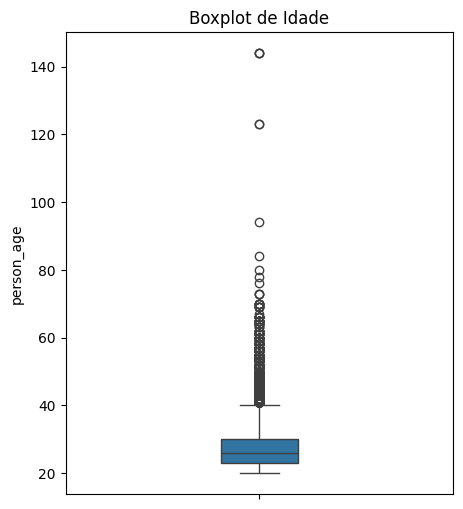

Idade máxima antes: 144
Mediana da Idade: 26.0
Quantidade acima de 100: 5
Porcentagem Outliers acima de 100: 0.0154%
Idade máxima depois de Tratado: 94


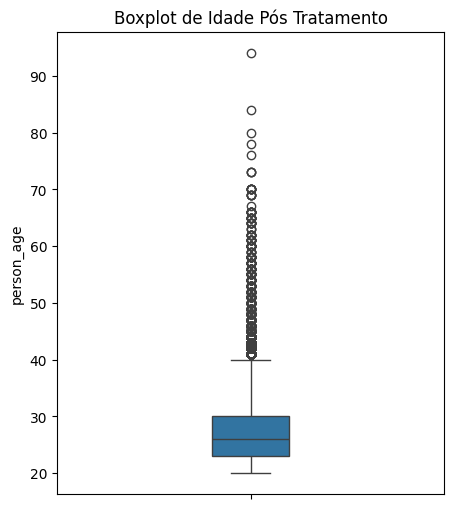

 ------------------------------------------------- 


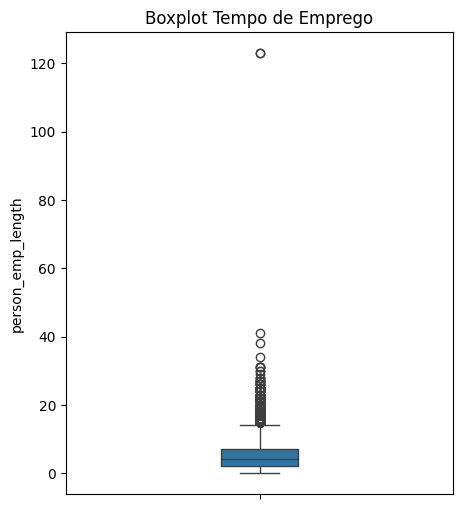

Linhas antes: 32411
Tempo Máximo de Emprego Antes 123.0
Quantidade Acima de 50: 2
Linhas depois: 32409
Tempo Máximo de Emprego depois de Tratado: 41.0


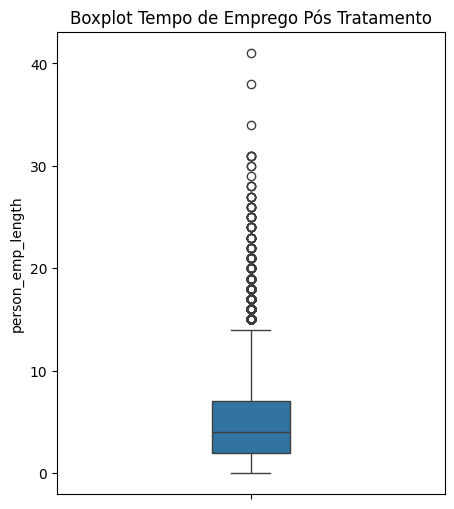

In [276]:
#BoxPlot Idade
plt.figure(figsize=(5, 6))
sns.boxplot(data=df_limpo['person_age'], width=0.2)
plt.title("Boxplot de Idade")
plt.show()

#Tratamento Idade
print("Idade máxima antes:", df_limpo['person_age'].max()) #Para fins de estatística
print("Mediana da Idade:", df_limpo['person_age'].median()) #Para fins de estatística
print("Quantidade acima de 100:", (df_limpo['person_age'] > 100).sum()) #Para fins de estatística
porcentagem = ((df_limpo["person_age"] > 100).mean() * 100) # Verificar a porcentagem de Outliers acima de 100
print(f"Porcentagem Outliers acima de 100: {porcentagem:.4f}%")

df_limpo = df_limpo[df_limpo['person_age'] < 100] #Tratamento dos dados via Remoção
print("Idade máxima depois de Tratado:", df_limpo['person_age'].max())

#BoxPlot Idade Após Tratamento
plt.figure(figsize=(5, 6))
sns.boxplot(data=df_limpo['person_age'], width=0.2)
plt.title("Boxplot de Idade Pós Tratamento")
plt.show()

print(" ------------------------------------------------- ")

#BoxPlot Tempo de Emprego 
plt.figure(figsize=(5, 6))
sns.boxplot(data=df_limpo['person_emp_length'], width=0.2)
plt.title("Boxplot Tempo de Emprego")
plt.show()

#Tratamento Tempo de Emprego - Remoção
print("Linhas antes:", df_limpo.shape[0])
print("Tempo Máximo de Emprego Antes", df_limpo['person_emp_length'].max())
print("Quantidade Acima de 50:", (df_limpo['person_emp_length'] > 50).sum())
df_limpo = df_limpo[df_limpo['person_emp_length'] < 50]
print("Linhas depois:", df_limpo.shape[0])
print("Tempo Máximo de Emprego depois de Tratado:", df_limpo['person_emp_length'].max())

#BoxPlot Tempo de Emprego Após Tratamento
plt.figure(figsize=(5, 6))
sns.boxplot(data=df_limpo['person_emp_length'], width=0.2)
plt.title("Boxplot Tempo de Emprego Pós Tratamento")
plt.show()



### 

#### Decisão Tratamento:
- Na coluna "person_age" (idade) foi identificado através do BoxPlot e Fase 1 EDA alguns Outliers considerados como "Artificiais" (Erros de digitação), cinco valores superiores a 100, um percentual de 0.0154% do total de registros, foi aplicado o "Tratamento de Remoção" excluindo os registros acima de 100, preservando outliers naturais(40 a 94) e mitigando inconsistências para uso nos modelos preditivos. 
- Coluna "person_emp_length" (Tempo de Emprego), após análise visual foi identificado 2 outliers extremos com valor máximo de 123 anos, em relação aos outliers naturais de no máximo 41. Foi aplicado o "Tratamento de Remoção" excluindo os registros acima de 50 anos visando preservar a integridade da base. 

#### Impacto nos Modelos: 
- KNN: Muito vulnerável a outliers, porque ele decide quem é parecido com quem calculando a distância entre os dados, reduzir outliers extremos é fundamental para que o modelo não cometa erros. Calcula a proximidade entre dados usando fórmulas de distância geométrica no espaço multidimensional
- Árvore de decisão: É mais robusta a outliers, porém pode sofrer overfitting criando galhos isolados, por isso é bom tratar outliers extremos.

# Fase 3: Feature Engineering (Coluna Calculada)

count    32409.000000
mean        17.059651
std         10.705381
min          0.078947
25%          8.972231
50%         14.814815
75%         22.916667
max         83.000000
Name: comprometimento_renda, dtype: float64

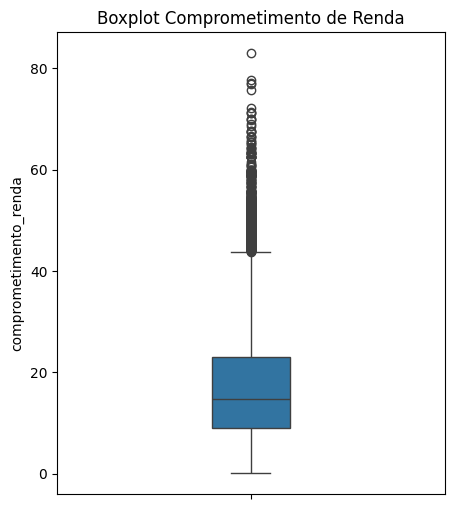

In [277]:
# Criando coluna comprometimento_renda
df_limpo['comprometimento_renda'] = (df_limpo['loan_amnt'] / df_limpo['person_income'])*100
display(df_limpo['comprometimento_renda'].describe())
#Visualizar Relação
df_limpo[["loan_amnt", "person_income", "comprometimento_renda"]].head()
#Verificar Outliers
plt.figure(figsize=(5, 6))
sns.boxplot(data=df_limpo['comprometimento_renda'], width=0.2)
plt.title("Boxplot Comprometimento de Renda")
plt.show()

# Fase 4: Separação, Balanceamento e Escalonamento Seguro

## Encoding

In [278]:
# Variável colunas categóricas e textuais
df_limpo_encoding = df_limpo.copy()

colunas = (df_limpo_encoding.select_dtypes(include='object').columns)
display(df_limpo_encoding[colunas].head(10))
display(df_limpo_encoding[colunas].nunique())

# Label Encoding em loan_grade (ordinal)
ordem_risco_grade = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7}
df_limpo_encoding["loan_grade"] = df_limpo_encoding["loan_grade"].map(ordem_risco_grade)

# Identificar colunas restantes (nominais)
colunas_para_ohe = df_limpo_encoding.select_dtypes(include='object').columns.tolist()
print("Colunas para One-Hot:", colunas_para_ohe)

# One-Hot Encoding
df_limpo_encoding = pd.get_dummies(df_limpo_encoding, columns=colunas_para_ohe, drop_first=True, dtype=int)

print("Dimensão final:", df_limpo_encoding.shape)
display(df_limpo_encoding.head())

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
1,OWN,EDUCATION,B,N
2,MORTGAGE,MEDICAL,C,N
3,RENT,MEDICAL,C,N
4,RENT,MEDICAL,C,Y
5,OWN,VENTURE,A,N
6,RENT,EDUCATION,B,N
7,RENT,MEDICAL,B,N
8,RENT,PERSONAL,A,N
9,OWN,VENTURE,D,N
10,RENT,VENTURE,B,N


person_home_ownership        4
loan_intent                  6
loan_grade                   7
cb_person_default_on_file    2
dtype: int64

Colunas para One-Hot: ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']
Dimensão final: (32409, 19)


,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,comprometimento_renda,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y
1,21,9600,5.0,2,1000,11.14,0,0.10,2,10.416667,0,1,0,1,0,0,0,0,0
2,25,9600,1.0,3,5500,12.87,1,0.57,3,57.291667,0,0,0,0,0,1,0,0,0
3,23,65500,4.0,3,35000,15.23,1,0.53,2,53.435115,0,0,1,0,0,1,0,0,0
4,24,54400,8.0,3,35000,14.27,1,0.55,4,64.338235,0,0,1,0,0,1,0,0,1
5,21,9900,2.0,1,2500,7.14,1,0.25,2,25.252525,0,1,0,0,0,0,0,1,0


## Split de Dados

In [279]:
from sklearn.model_selection import train_test_split

X = df_limpo_encoding.drop('loan_status', axis=1)
y = df_limpo_encoding['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("Tamanho X_train:", X_train.shape)
print("Tamanho X_test:", X_test.shape)
print("Tamanho y_train:", y_train.shape)
print("Tamanho y_test:", y_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Tamanho X_train: (25927, 18)
Tamanho X_test: (6482, 18)
Tamanho y_train: (25927,)
Tamanho y_test: (6482,)
loan_status
0    0.781309
1    0.218691
Name: proportion, dtype: float64
loan_status
0    0.78124
1    0.21876
Name: proportion, dtype: float64


## Balançeamento de Classes

In [280]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Antes do balanceamento:")
print(y_train.value_counts())

print("\nDepois do balanceamento:")
print(y_train_balanced.value_counts())

Antes do balanceamento:
loan_status
0    20257
1     5670
Name: count, dtype: int64

Depois do balanceamento:
loan_status
0    20257
1    20257
Name: count, dtype: int64


## Escalonamento Seguro

### KNN

In [281]:
from sklearn.preprocessing import StandardScaler

# Identificar colunas contínuas (não binárias, não já codificadas)
colunas_continuas = ['person_age', 'person_income', 'person_emp_length', 'loan_grade', 
                      'loan_amnt', 'loan_int_rate', 'loan_percent_income', 
                      'cb_person_cred_hist_length', 'comprometimento_renda']

scaler = StandardScaler()

X_train_knn = X_train_balanced.copy()
X_test_knn = X_test.copy()

X_train_knn[colunas_continuas] = scaler.fit_transform(X_train_balanced[colunas_continuas])
X_test_knn[colunas_continuas] = scaler.transform(X_test[colunas_continuas])

print("Treino escalonado (KNN) - exemplo:")
display(X_train_knn.head())

Treino escalonado (KNN) - exemplo:


,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,comprometimento_renda,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y
0,1.658901,0.521717,3.912587,-0.329961,-0.002519,-0.552080,-0.636565,2.754658,-0.660681,0,0,0,0,1,0,0,0,0
1,-0.410843,-0.203645,0.670619,2.211650,-0.229812,1.227432,-0.224145,-0.409731,-0.230310,0,0,1,1,0,0,0,0,0
2,-0.238364,0.625340,-0.950366,-0.329961,1.512772,-0.240432,0.188275,-0.673430,0.198986,0,0,0,0,0,0,1,0,0
3,2.348816,0.598647,-0.680202,-0.329961,0.906656,-0.252897,-0.141661,2.490959,-0.145154,0,0,1,0,0,0,0,1,0
4,1.313944,-0.431616,-0.680202,0.517243,-0.002519,0.435845,0.518211,0.117667,0.480031,0,0,1,0,0,1,0,0,0


### Árvore de Decisão (sem escalonamento)

In [282]:
# Árvore de Decisão usa os dados balanceados SEM escalonamento
X_train_arvore = X_train_balanced.copy()
X_test_arvore = X_test.copy()

print("Árvore de Decisão - dimensão do treino:", X_train_arvore.shape)

Árvore de Decisão - dimensão do treino: (40514, 18)


### Justificativa: Árvore de Decisão sem Escalonamento
A Árvore de Decisão foi treinada sem aplicação do StandardScaler, pois esse algoritmo realiza cortes (splits) baseados em limiares de valor (ex: "loan_percent_income > 25"), sendo portanto invariante à escala das variáveis. Diferente do KNN, que depende do cálculo de distância euclidiana entre os pontos, a Árvore compara apenas se um valor está acima ou abaixo de um determinado limiar, a transformação de escala não altera a ordem relativa dos valores, logo não influencia o resultado das divisões.

## Fase 5 - Modelagem e Validação

### Otimização do KNN - Gráficos

,K,Acurácia Treino,Acurácia Teste
0,3,0.935504,0.832768
1,5,0.916301,0.828911
2,7,0.905662,0.831996
3,9,0.899492,0.834002


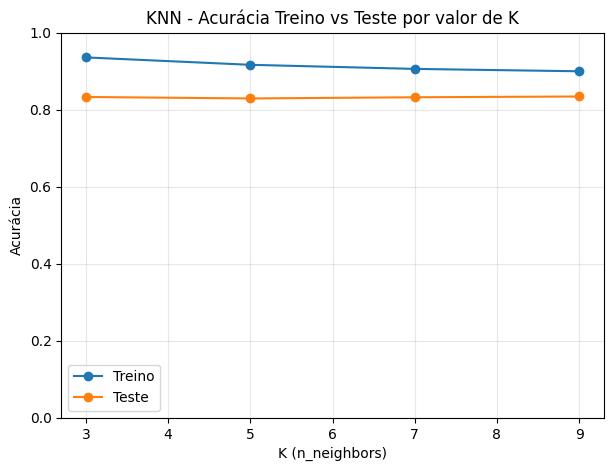

In [283]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

valores_k = [3, 5, 7, 9]
resultados_knn = []

for k in valores_k:
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_train_knn, y_train_balanced)
    
    acuracia_treino = accuracy_score(y_train_balanced, modelo.predict(X_train_knn))
    acuracia_teste = accuracy_score(y_test, modelo.predict(X_test_knn))
    
    resultados_knn.append({'K': k, 'Acurácia Treino': acuracia_treino, 'Acurácia Teste': acuracia_teste})

df_resultados_knn = pd.DataFrame(resultados_knn)
display(df_resultados_knn)

#Gráficos
plt.figure(figsize=(7, 5))
plt.plot(df_resultados_knn['K'], df_resultados_knn['Acurácia Treino'], marker='o', label='Treino')
plt.plot(df_resultados_knn['K'], df_resultados_knn['Acurácia Teste'], marker='o', label='Teste')
plt.title('KNN - Acurácia Treino vs Teste por valor de K')
plt.xlabel('K (n_neighbors)')
plt.ylabel('Acurácia')
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Otimização Árvore de Decisão - Gráficos

,max_depth,Acurácia Treino,Acurácia Teste
0,3.0,0.815521,0.834927
1,5.0,0.838969,0.876427
2,7.0,0.855482,0.827522
3,NaN,1.000000,0.859611


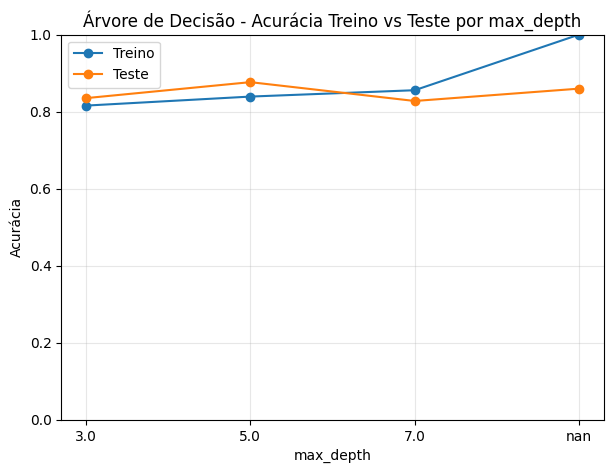

In [284]:
from sklearn.tree import DecisionTreeClassifier

profundidades = [3, 5, 7, None]
resultados_arvore = []

for profundidade in profundidades:
    modelo = DecisionTreeClassifier(max_depth=profundidade, random_state=42)
    modelo.fit(X_train_arvore, y_train_balanced)
    
    acuracia_treino = accuracy_score(y_train_balanced, modelo.predict(X_train_arvore))
    acuracia_teste = accuracy_score(y_test, modelo.predict(X_test_arvore))
    
    resultados_arvore.append({'max_depth': profundidade, 'Acurácia Treino': acuracia_treino, 'Acurácia Teste': acuracia_teste})

df_resultados_arvore = pd.DataFrame(resultados_arvore)
display(df_resultados_arvore)

plt.figure(figsize=(7, 5))
plt.plot(df_resultados_arvore['max_depth'].astype(str), df_resultados_arvore['Acurácia Treino'], marker='o', label='Treino')
plt.plot(df_resultados_arvore['max_depth'].astype(str), df_resultados_arvore['Acurácia Teste'], marker='o', label='Teste')
plt.title('Árvore de Decisão - Acurácia Treino vs Teste por max_depth')
plt.xlabel('max_depth')
plt.ylabel('Acurácia')
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()



### Diagnóstico de Overfitting

No KNN, observou-se que valores baixos de K (ex: K=3) geram alta acurácia no treino (93,55%), mas uma queda significativa no teste (83,28%), evidenciando overfitting. Conforme K aumenta, essa diferença diminui, sendo K=9 a 
configuração mais equilibrada, com a menor diferença entre treino e teste e a maior acurácia de teste (83,40%).

Na Árvore de Decisão, o cenário mais extremo de overfitting ocorreu com profundidade ilimitada, que atingiu 100% de acurácia no treino, mas apenas 85,96% no teste, um sinal claro de que o modelo memorizou os dados de treino em vez de aprender um padrão generalizável. A configuração com max_depth=5 apresentou o melhor equilíbrio, com a maior acurácia de teste entre todas as profundidades testadas (87,64%), sendo a escolhida como melhor configuração da Árvore.

## Fase 6: Avaliação e Veredito de Negócios

### Melhor Configuração

In [285]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Melhor KNN
melhor_knn = KNeighborsClassifier(n_neighbors=9)
melhor_knn.fit(X_train_knn, y_train_balanced)

# Melhor Árvore
melhor_arvore = DecisionTreeClassifier(max_depth=5, random_state=42)
melhor_arvore.fit(X_train_arvore, y_train_balanced)

print("Modelos treinados com as melhores configurações.")

Modelos treinados com as melhores configurações.


### Classification Report

In [286]:
from sklearn.metrics import classification_report

# Previsões no teste
pred_knn = melhor_knn.predict(X_test_knn)
pred_arvore = melhor_arvore.predict(X_test_arvore)

print("Classification Report - KNN (K=9)")
print(classification_report(y_test, pred_knn))

print("\nClassification Report - Árvore de Decisão (max_depth=5)")
print(classification_report(y_test, pred_arvore))

Classification Report - KNN (K=9)
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      5064
           1       0.60      0.73      0.66      1418

    accuracy                           0.83      6482
   macro avg       0.76      0.80      0.77      6482
weighted avg       0.85      0.83      0.84      6482


Classification Report - Árvore de Decisão (max_depth=5)
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      5064
           1       0.71      0.72      0.72      1418

    accuracy                           0.88      6482
   macro avg       0.82      0.82      0.82      6482
weighted avg       0.88      0.88      0.88      6482



### Matriz de Confusão

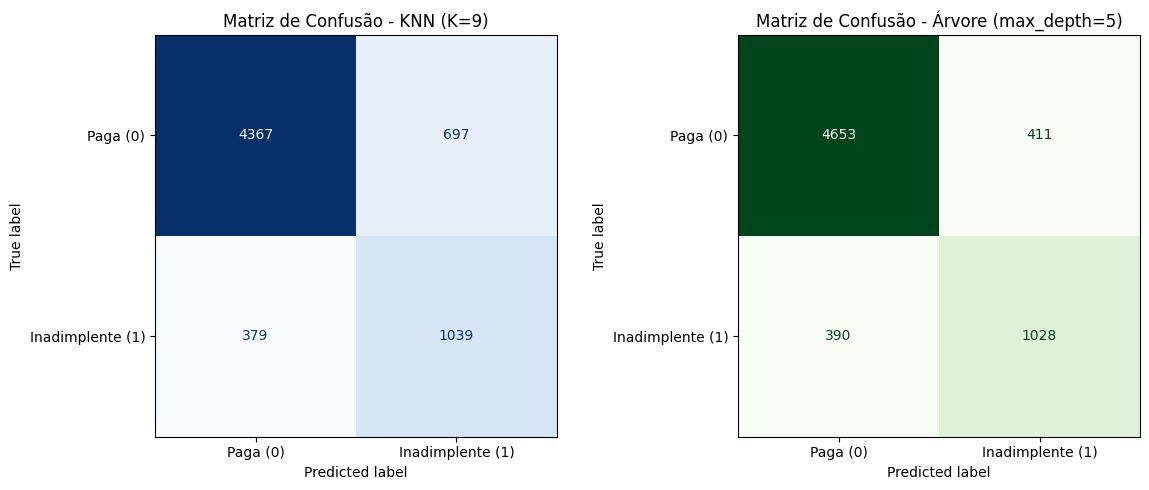

In [287]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_knn = confusion_matrix(y_test, pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Paga (0)', 'Inadimplente (1)'])
disp_knn.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusão - KNN (K=9)')

cm_arvore = confusion_matrix(y_test, pred_arvore)
disp_arvore = ConfusionMatrixDisplay(confusion_matrix=cm_arvore, display_labels=['Paga (0)', 'Inadimplente (1)'])
disp_arvore.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Matriz de Confusão - Árvore (max_depth=5)')

plt.tight_layout()
plt.show()

### Fase 6: Análise de Negócio

**Comparação das Métricas**

Ambos os modelos foram avaliados nas suas melhores configurações (KNN com K=9 e Árvore de Decisão com max_depth=5). A Árvore apresentou desempenho geral superior, com acurácia de 88% contra 83% do KNN, além de maior precision na classe "Inadimplente" (0,71 vs 0,60). O recall dessa mesma classe, capacidade de identificar corretamente os clientes que de fato não pagam, ficou praticamente equivalente entre os dois modelos (72% na Árvore, 73% no KNN).

**Análise dos Erros (Matriz de Confusão)**

- Falso Positivo (bom pagador classificado como risco): KNN comete 697 erros, contra 411 da Árvore.
- Falso Negativo (mau pagador classificado como seguro): KNN comete 379 erros, contra 390 da Árvore, uma diferença pequena e praticamente 
equivalente entre os dois modelos.

**Impacto Financeiro**

O Falso Negativo tende a ser o erro mais custoso para o banco, pois representa capital emprestado que não retorna, uma perda direta. Já o Falso Positivo 
representa apenas um custo de oportunidade (deixar de lucrar com um bom cliente rejeitado). Como os dois modelos apresentam um número de Falsos 
Negativos muito próximo (379 vs 390), a diferença decisiva está no Falso Positivo, onde a Árvore comete 286 erros a menos que o KNN, rejeitando 
significativamente menos clientes bons, sem comprometer a capacidade de identificar os maus pagadores.

**Veredito Final**

Diante da análise, a Árvore de Decisão (max_depth=5) é o modelo recomendado para produção. Ela mantém uma capacidade equivalente ao KNN em identificar clientes de risco (o erro financeiramente mais grave), enquanto reduz significativamente a rejeição indevida de bons pagadores, o que se traduz em maior receita para o banco sem aumento proporcional do risco de crédito.